# Mini Project 8: Flood Area Segmentation
### PyTorch + CUDA Version

## 1. Setup & Imports

In [1]:
# ============================================================
# Install dependencies (run once in terminal):
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
# pip install kaggle scikit-learn matplotlib numpy pillow tqdm
# ============================================================
import os
import glob
import zipfile
import itertools
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

# ---- GPU check ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Using device: {DEVICE}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch version: 2.5.1+cu121
CUDA available:  True
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.9 GB
Using device: cuda


## 2. Configuration

In [6]:
# ============================================================
# CONFIGURATION
# ============================================================
IMG_SIZE     = 640   # High-res
IMG_SIZE_LOW = 256   # Low-res for resolution comparison
BATCH_SIZE   = 4     # Reduce to 2 if you get OOM at 640x640
NUM_CLASSES  = 2     # 0 = Background, 1 = Flood
EPOCHS_SIMPLE = 5
EPOCHS_FULL   = 35
LR            = 1e-3

CLASS_NAMES = ['Background', 'Flood']
COLORMAP    = np.array([[30, 100, 200], [255, 140, 0]], dtype=np.uint8)

DATA_DIR  = 'data/flood_data'
IMAGE_DIR = os.path.join(DATA_DIR, 'Image')
MASK_DIR  = os.path.join(DATA_DIR, 'Mask')

os.makedirs('checkpoints', exist_ok=True)

print(f"IMG_SIZE:    {IMG_SIZE}x{IMG_SIZE}")
print(f"BATCH_SIZE:  {BATCH_SIZE}")
print(f"NUM_CLASSES: {NUM_CLASSES} -> {CLASS_NAMES}")

IMG_SIZE:    640x640
BATCH_SIZE:  4
NUM_CLASSES: 2 -> ['Background', 'Flood']


## 3. Download Dataset

In [7]:
import zipfile, os, glob

zip_path = 'data/flood-area-segmentation.zip'
DATA_DIR  = 'data/flood_data'
IMAGE_DIR = os.path.join(DATA_DIR, 'Image')
MASK_DIR  = os.path.join(DATA_DIR, 'Mask')

if not os.path.exists(DATA_DIR):
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    print("Done")
else:
    print(f"Already extracted to {DATA_DIR}")

image_files = sorted(glob.glob(os.path.join(IMAGE_DIR, '*')))
mask_files  = sorted(glob.glob(os.path.join(MASK_DIR,  '*')))
print(f"Images: {len(image_files)} | Masks: {len(mask_files)}")

Unzipping...
Done
Images: 290 | Masks: 290


## 4. Clean Corrupt Files

In [8]:
# ============================================================
# Remove corrupt image/mask pairs
# ============================================================
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

def cleanup_dataset(image_path, mask_path):
    image_path = Path(image_path)
    mask_path  = Path(mask_path)
    print("--- Starting Cleanup ---")
    corrupt_count = 0
    for img_file in list(image_path.rglob('*')):
        if img_file.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        try:
            Image.open(img_file).verify()
        except Exception:
            print(f"Corrupt: {img_file.name}")
            mask_options = [
                mask_path / img_file.name,
                mask_path / img_file.with_suffix('.png').name,
            ]
            img_file.unlink()
            for m in mask_options:
                if m.exists():
                    m.unlink()
                    break
            corrupt_count += 1
    print(f"Removed {corrupt_count} corrupt pairs")
    print(f"Remaining: {len(list(image_path.glob('*')))} images")

cleanup_dataset(IMAGE_DIR, MASK_DIR)

--- Starting Cleanup ---
Removed 0 corrupt pairs
Remaining: 290 images


## 5. Dataset & DataLoader

In [10]:
# ============================================================
# PyTorch Dataset — loads image/mask pairs
# ============================================================
class FloodDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size, augment=False):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.img_size    = img_size
        self.augment     = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load
        image = Image.open(self.image_paths[idx]).convert('RGB')
        mask  = Image.open(self.mask_paths[idx]).convert('L')

        # Resize — BILINEAR for image, NEAREST for mask
        image = TF.resize(image, (self.img_size, self.img_size), interpolation=Image.BILINEAR)
        mask  = TF.resize(mask,  (self.img_size, self.img_size), interpolation=Image.NEAREST)

        # Synchronized augmentation
        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask  = TF.vflip(mask)
            # Colour jitter — image only
            image = TF.adjust_brightness(image, 1.0 + random.uniform(-0.1, 0.1))
            image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))

        # To tensor
        image = TF.to_tensor(image)                          # (3, H, W) float32 in [0,1]
        mask  = torch.from_numpy(np.array(mask)).long()      # (H, W) int64
        mask  = (mask > 127).long()                          # Binarize: 0 or 1

        return image, mask


# ---- Build train/val/test splits ----
def get_stem(path):
    return os.path.splitext(os.path.basename(path))[0]

image_stems = {get_stem(f): f for f in sorted(glob.glob(os.path.join(IMAGE_DIR, '*')))}
mask_stems  = {get_stem(f): f for f in sorted(glob.glob(os.path.join(MASK_DIR,  '*')))}
common_stems = sorted(set(image_stems.keys()) & set(mask_stems.keys()))

image_paths = [image_stems[s] for s in common_stems]
mask_paths  = [mask_stems[s]  for s in common_stems]

n       = len(image_paths)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

rng = np.random.RandomState(SEED)
idx = rng.permutation(n)
image_paths = [image_paths[i] for i in idx]
mask_paths  = [mask_paths[i]  for i in idx]

train_imgs, train_masks = image_paths[:n_train],              mask_paths[:n_train]
val_imgs,   val_masks   = image_paths[n_train:n_train+n_val], mask_paths[n_train:n_train+n_val]
test_imgs,  test_masks  = image_paths[n_train+n_val:],        mask_paths[n_train+n_val:]

print(f"Matched pairs: {n}")
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")


# ---- DataLoaders — high-res (640) ----
train_loader = DataLoader(FloodDataset(train_imgs, train_masks, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader   = DataLoader(FloodDataset(val_imgs, val_masks, IMG_SIZE, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(FloodDataset(test_imgs, test_masks, IMG_SIZE, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

train_loader_low = DataLoader(FloodDataset(train_imgs, train_masks, IMG_SIZE_LOW, augment=True),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader_low   = DataLoader(FloodDataset(val_imgs, val_masks, IMG_SIZE_LOW, augment=False),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader_low  = DataLoader(FloodDataset(test_imgs, test_masks, IMG_SIZE_LOW, augment=False),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

# Verify shapes
imgs, msks = next(iter(train_loader))
print(f"\nBatch — image: {imgs.shape} {imgs.dtype} | mask: {msks.shape} {msks.dtype}")
print(f"Mask unique values: {msks.unique().tolist()}")

Matched pairs: 290
Train: 203 | Val: 43 | Test: 44

Batch — image: torch.Size([4, 3, 640, 640]) torch.float32 | mask: torch.Size([4, 640, 640]) torch.int64
Mask unique values: [0, 1]


## 6. Explore Data

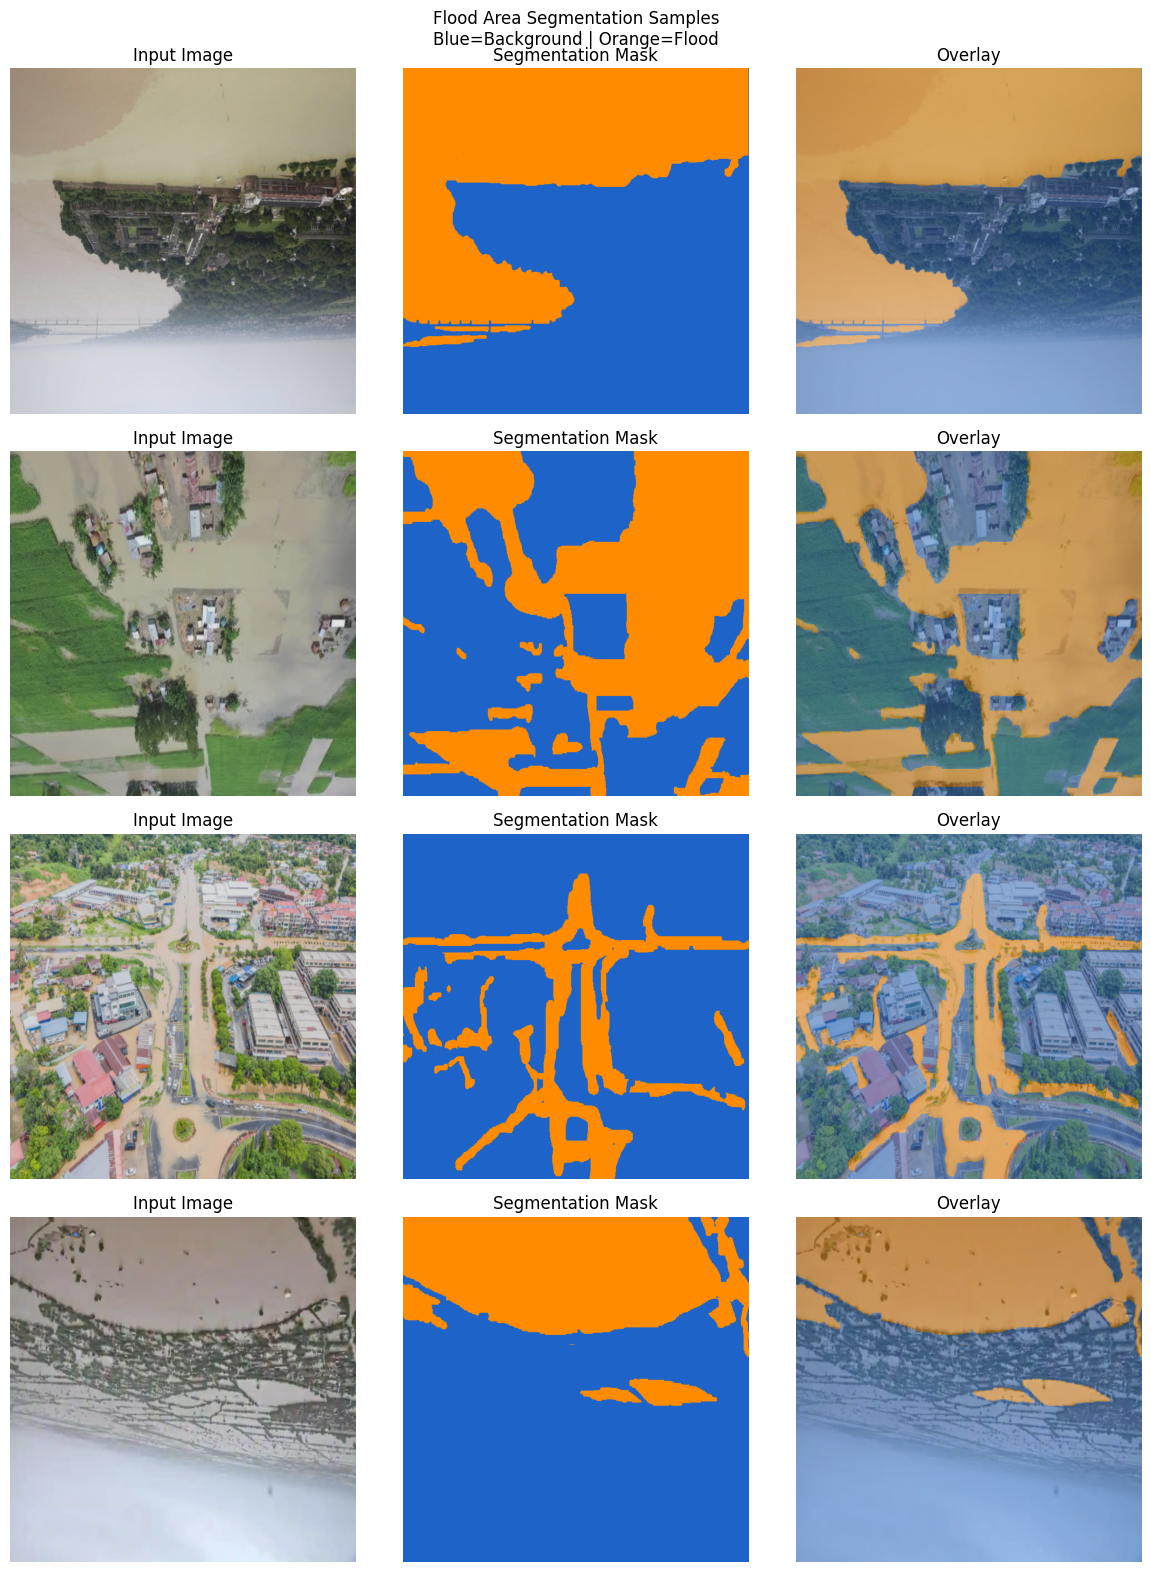


Class distribution (first 10 batches):
  Background: 64.2%
  Flood: 35.8%


In [11]:
# ============================================================
# Visualize samples
# ============================================================
def show_samples(loader, num_samples=4):
    images, masks = next(iter(loader))
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    for i in range(min(num_samples, len(images))):
        img = images[i].permute(1, 2, 0).numpy()  # (H,W,3)
        msk = masks[i].numpy()
        mask_colored = COLORMAP[msk]
        overlay = np.clip(img * 0.6 + mask_colored / 255.0 * 0.4, 0, 1)
        axes[i, 0].imshow(img);           axes[i, 0].set_title('Input Image');       axes[i, 0].axis('off')
        axes[i, 1].imshow(mask_colored);  axes[i, 1].set_title('Segmentation Mask'); axes[i, 1].axis('off')
        axes[i, 2].imshow(overlay);       axes[i, 2].set_title('Overlay');           axes[i, 2].axis('off')
    plt.suptitle('Flood Area Segmentation Samples\nBlue=Background | Orange=Flood')
    plt.tight_layout(); plt.show()

show_samples(train_loader)

# Class distribution
class_counts = np.zeros(NUM_CLASSES)
for _, masks in list(train_loader)[:10]:
    for c in range(NUM_CLASSES):
        class_counts[c] += (masks == c).sum().item()
total = class_counts.sum()
print(f"\nClass distribution (first 10 batches):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {class_counts[i]/total*100:.1f}%")

## 7. U-Net Model

In [12]:
# ============================================================
# U-Net in PyTorch
# ============================================================
class ConvBlock(nn.Module):
    """Two conv layers with BN and ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=2, features=[32, 64, 128, 256]):
        super().__init__()
        self.encoders  = nn.ModuleList()
        self.pools     = nn.ModuleList()
        self.decoders  = nn.ModuleList()
        self.upconvs   = nn.ModuleList()

        # Encoder
        in_ch = in_channels
        for f in features:
            self.encoders.append(ConvBlock(in_ch, f))
            self.pools.append(nn.MaxPool2d(2))
            in_ch = f

        # Bottleneck
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        # Decoder
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.decoders.append(ConvBlock(f * 2, f))

        # Output
        self.output_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skips = []
        # Encode
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)
        # Bottleneck
        x = self.bottleneck(x)
        # Decode
        for upconv, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = upconv(x)
            # Handle size mismatch from odd input dimensions
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = dec(x)
        return self.output_conv(x)  # (B, num_classes, H, W)


# Test model
model_test = UNet(num_classes=NUM_CLASSES).to(DEVICE)
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model_test(dummy)
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}  (expected: [1, {NUM_CLASSES}, {IMG_SIZE}, {IMG_SIZE}])")
total_params = sum(p.numel() for p in model_test.parameters())
print(f"Parameters: {total_params:,}")
del model_test, dummy, out

Input:  torch.Size([1, 3, 640, 640])
Output: torch.Size([1, 2, 640, 640])  (expected: [1, 2, 640, 640])
Parameters: 7,766,018


## 8. Loss Functions

In [13]:
# ============================================================
# Cross-Entropy and Dice Loss
# ============================================================
ce_loss_fn = nn.CrossEntropyLoss()  # expects (B, C, H, W) logits and (B, H, W) targets

def dice_loss(logits, targets, num_classes=NUM_CLASSES, smooth=1e-6):
    probs    = F.softmax(logits, dim=1)                           # (B, C, H, W)
    targets_oh = F.one_hot(targets, num_classes).permute(0,3,1,2).float()  # (B, C, H, W)
    dims     = (0, 2, 3)  # sum over batch, H, W
    intersection = (probs * targets_oh).sum(dims)
    cardinality  = (probs + targets_oh).sum(dims)
    dice_per_class = (2.0 * intersection + smooth) / (cardinality + smooth)
    return 1.0 - dice_per_class.mean()

def combined_loss(logits, targets):
    return ce_loss_fn(logits, targets) + dice_loss(logits, targets)

print("Loss functions defined: ce_loss_fn, dice_loss, combined_loss")

Loss functions defined: ce_loss_fn, dice_loss, combined_loss


## 9. Training & Evaluation Utilities

In [14]:
# ============================================================
# Training loop
# ============================================================
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, masks in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss   = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds   = logits.argmax(dim=1)
        correct += (preds == masks).sum().item()
        total   += masks.numel()
    return total_loss / len(loader.dataset), correct / total


@torch.no_grad()
def evaluate_epoch(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, masks in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images)
        loss   = loss_fn(logits, masks)
        total_loss += loss.item() * images.size(0)
        preds   = logits.argmax(dim=1)
        correct += (preds == masks).sum().item()
        total   += masks.numel()
    return total_loss / len(loader.dataset), correct / total


def train_model(model, train_loader, val_loader, loss_fn, ckpt_path,
                epochs=EPOCHS_FULL, lr=LR, patience=15, min_delta=0.01):
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-7, verbose=True
    )
    history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val   = float('inf')
    no_improve = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, loss_fn)
        vl_loss, vl_acc = evaluate_epoch(model, val_loader, loss_fn)
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        improved = vl_loss < best_val - min_delta
        flag     = ' *saved*' if improved else ''
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {vl_loss:.4f} acc {vl_acc:.4f}{flag}")

        if improved:
            best_val   = vl_loss
            no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # Restore best weights
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f"Restored best weights from {ckpt_path}")
    return history


print("Training utilities defined")

Training utilities defined


## 10. Quick Demo — Simplified U-Net (5 epochs)

In [15]:
# ============================================================
# 5-epoch demo using a 3-level U-Net
# ============================================================
simple_unet = UNet(num_classes=NUM_CLASSES, features=[32, 64, 128]).to(DEVICE)
print(f"Simple U-Net params: {sum(p.numel() for p in simple_unet.parameters()):,}")

simple_history = train_model(
    simple_unet, train_loader, val_loader,
    loss_fn=ce_loss_fn,
    ckpt_path='checkpoints/simple_unet.pth',
    epochs=EPOCHS_SIMPLE
)

Simple U-Net params: 1,928,450


c:\Users\jchen\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/5 | train loss 0.4635 acc 0.7902 | val loss 0.6279 acc 0.7632 *saved*
Epoch 02/5 | train loss 0.4201 acc 0.8115 | val loss 1.0734 acc 0.6332
Epoch 03/5 | train loss 0.4074 acc 0.8193 | val loss 0.4620 acc 0.8213 *saved*
Epoch 04/5 | train loss 0.4138 acc 0.8052 | val loss 0.4366 acc 0.8057 *saved*
Epoch 05/5 | train loss 0.4021 acc 0.8236 | val loss 0.5653 acc 0.7924
Restored best weights from checkpoints/simple_unet.pth


C:\Users\jchen\AppData\Local\Temp\ipykernel_29804\1119588118.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE

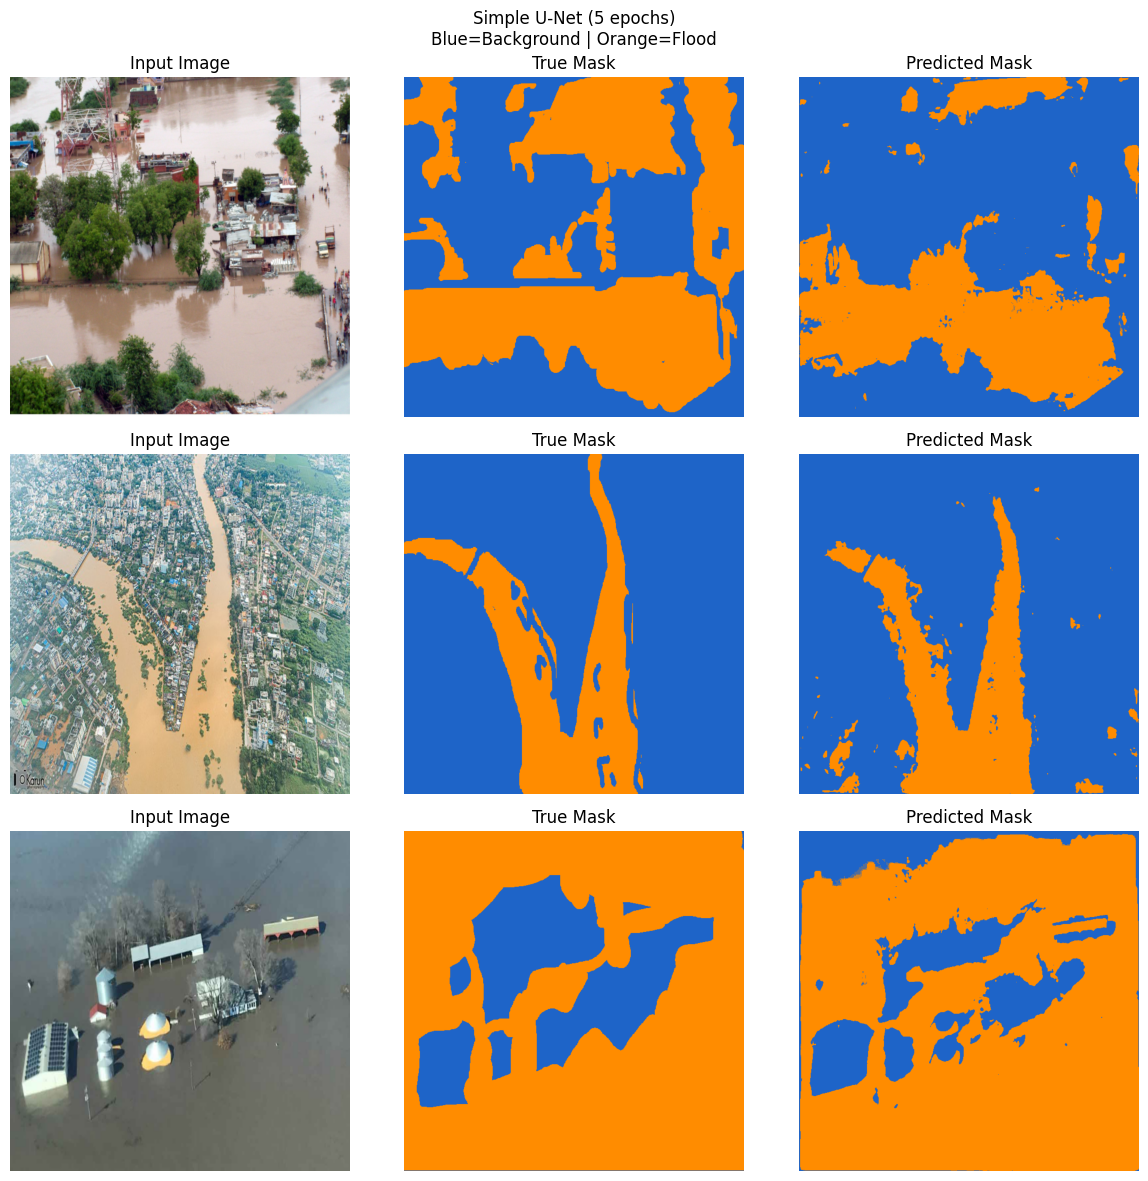

In [16]:
# ============================================================
# Quick prediction visualization
# ============================================================
@torch.no_grad()
def show_predictions(model, loader, num_samples=3, title='Predictions'):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(DEVICE)
    logits = model(images)
    preds  = logits.argmax(dim=1).cpu().numpy()
    images = images.cpu().permute(0, 2, 3, 1).numpy()
    masks  = masks.numpy()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    for i in range(num_samples):
        axes[i, 0].imshow(images[i]);              axes[i, 0].set_title('Input Image');    axes[i, 0].axis('off')
        axes[i, 1].imshow(COLORMAP[masks[i]]);     axes[i, 1].set_title('True Mask');      axes[i, 1].axis('off')
        axes[i, 2].imshow(COLORMAP[preds[i]]);     axes[i, 2].set_title('Predicted Mask'); axes[i, 2].axis('off')
    plt.suptitle(f'{title}\nBlue=Background | Orange=Flood', fontsize=12)
    plt.tight_layout(); plt.show()

show_predictions(simple_unet, test_loader, title='Simple U-Net (5 epochs)')

## 11. Train Full U-Net — Model A (CE) and Model B (CE+Dice)

In [17]:
# ============================================================
# Model A — Cross-Entropy loss, 640x640
# ============================================================
full_unet_ce = UNet(num_classes=NUM_CLASSES, features=[32, 64, 128, 256]).to(DEVICE)
print(f"Full U-Net params: {sum(p.numel() for p in full_unet_ce.parameters()):,}")
print(f"Simple vs Full: {sum(p.numel() for p in full_unet_ce.parameters()) / sum(p.numel() for p in simple_unet.parameters()):.1f}x larger")

print("\nTraining Model A (CE loss) at 640x640...")
ce_history = train_model(
    full_unet_ce, train_loader, val_loader,
    loss_fn=ce_loss_fn,
    ckpt_path='checkpoints/unet_ce_best.pth',
    epochs=EPOCHS_FULL
)

Full U-Net params: 7,766,018
Simple vs Full: 4.0x larger

Training Model A (CE loss) at 640x640...
Epoch 01/35 | train loss 0.4730 acc 0.7843 | val loss 0.5044 acc 0.7543 *saved*
Epoch 02/35 | train loss 0.4239 acc 0.8107 | val loss 0.5454 acc 0.8045
Epoch 03/35 | train loss 0.4162 acc 0.8153 | val loss 0.4692 acc 0.7961 *saved*
Epoch 04/35 | train loss 0.4128 acc 0.8166 | val loss 0.4800 acc 0.7867
Epoch 05/35 | train loss 0.4150 acc 0.8188 | val loss 0.4745 acc 0.7931
Epoch 06/35 | train loss 0.4265 acc 0.8111 | val loss 0.8900 acc 0.5700
Epoch 07/35 | train loss 0.3940 acc 0.8293 | val loss 0.5125 acc 0.7874
Epoch 08/35 | train loss 0.4091 acc 0.8196 | val loss 0.4742 acc 0.8127
Epoch 09/35 | train loss 0.4139 acc 0.8175 | val loss 0.4903 acc 0.7873
Epoch 10/35 | train loss 0.4031 acc 0.8224 | val loss 0.4383 acc 0.8072 *saved*
Epoch 11/35 | train loss 0.3953 acc 0.8258 | val loss 0.4139 acc 0.8222 *saved*
Epoch 12/35 | train loss 0.3870 acc 0.8323 | val loss 0.5747 acc 0.7341
Epoch

C:\Users\jchen\AppData\Local\Temp\ipykernel_29804\1119588118.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE

In [18]:
# ============================================================
# Model B — CE + Dice loss, 640x640
# ============================================================
full_unet_dice = UNet(num_classes=NUM_CLASSES, features=[32, 64, 128, 256]).to(DEVICE)

print("Training Model B (CE + Dice loss) at 640x640...")
dice_history = train_model(
    full_unet_dice, train_loader, val_loader,
    loss_fn=combined_loss,
    ckpt_path='checkpoints/unet_dice_best.pth',
    epochs=EPOCHS_FULL
)

Training Model B (CE + Dice loss) at 640x640...
Epoch 01/35 | train loss 0.7787 acc 0.7878 | val loss 0.7801 acc 0.8076 *saved*
Epoch 02/35 | train loss 0.7110 acc 0.8104 | val loss 0.7396 acc 0.7896 *saved*
Epoch 03/35 | train loss 0.6729 acc 0.8189 | val loss 0.7122 acc 0.8222 *saved*
Epoch 04/35 | train loss 0.6538 acc 0.8263 | val loss 0.7752 acc 0.7951
Epoch 05/35 | train loss 0.6771 acc 0.8184 | val loss 1.0480 acc 0.7439
Epoch 06/35 | train loss 0.6510 acc 0.8327 | val loss 0.6611 acc 0.8296 *saved*
Epoch 07/35 | train loss 0.6269 acc 0.8345 | val loss 0.6650 acc 0.8227
Epoch 08/35 | train loss 0.6303 acc 0.8296 | val loss 0.6860 acc 0.8184
Epoch 09/35 | train loss 0.6576 acc 0.8232 | val loss 0.7793 acc 0.7972
Epoch 10/35 | train loss 0.6165 acc 0.8349 | val loss 0.7435 acc 0.8361
Epoch 11/35 | train loss 0.6117 acc 0.8360 | val loss 0.6399 acc 0.8396 *saved*
Epoch 12/35 | train loss 0.6061 acc 0.8438 | val loss 0.6108 acc 0.8428 *saved*
Epoch 13/35 | train loss 0.6024 acc 0.84

C:\Users\jchen\AppData\Local\Temp\ipykernel_29804\1119588118.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE

## 12. Train Low-Res Model (256x256) — Resolution Comparison

In [19]:
# ============================================================
# Same architecture at 256x256 — resolution comparison
# ============================================================
unet_low_res = UNet(num_classes=NUM_CLASSES, features=[32, 64, 128, 256]).to(DEVICE)

print("Training low-res model (CE loss) at 256x256...")
low_res_history = train_model(
    unet_low_res, train_loader_low, val_loader_low,
    loss_fn=ce_loss_fn,
    ckpt_path='checkpoints/unet_low_res_best.pth',
    epochs=EPOCHS_FULL
)

Training low-res model (CE loss) at 256x256...
Epoch 01/35 | train loss 0.4668 acc 0.7844 | val loss 0.4833 acc 0.7602 *saved*
Epoch 02/35 | train loss 0.4208 acc 0.8125 | val loss 0.8331 acc 0.5680
Epoch 03/35 | train loss 0.4074 acc 0.8191 | val loss 0.6393 acc 0.7127
Epoch 04/35 | train loss 0.4074 acc 0.8190 | val loss 0.4317 acc 0.8172 *saved*
Epoch 05/35 | train loss 0.3954 acc 0.8280 | val loss 0.4165 acc 0.8288 *saved*
Epoch 06/35 | train loss 0.3916 acc 0.8267 | val loss 0.4870 acc 0.7847
Epoch 07/35 | train loss 0.3878 acc 0.8252 | val loss 0.4777 acc 0.7741
Epoch 08/35 | train loss 0.3869 acc 0.8294 | val loss 0.3869 acc 0.8404 *saved*
Epoch 09/35 | train loss 0.3668 acc 0.8416 | val loss 0.4524 acc 0.8015
Epoch 10/35 | train loss 0.3757 acc 0.8382 | val loss 0.3961 acc 0.8424
Epoch 11/35 | train loss 0.3583 acc 0.8454 | val loss 0.3935 acc 0.8321
Epoch 12/35 | train loss 0.3804 acc 0.8361 | val loss 0.4094 acc 0.8255
Epoch 13/35 | train loss 0.3854 acc 0.8322 | val loss 0.4

C:\Users\jchen\AppData\Local\Temp\ipykernel_29804\1119588118.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE

## 13. Training History Plots

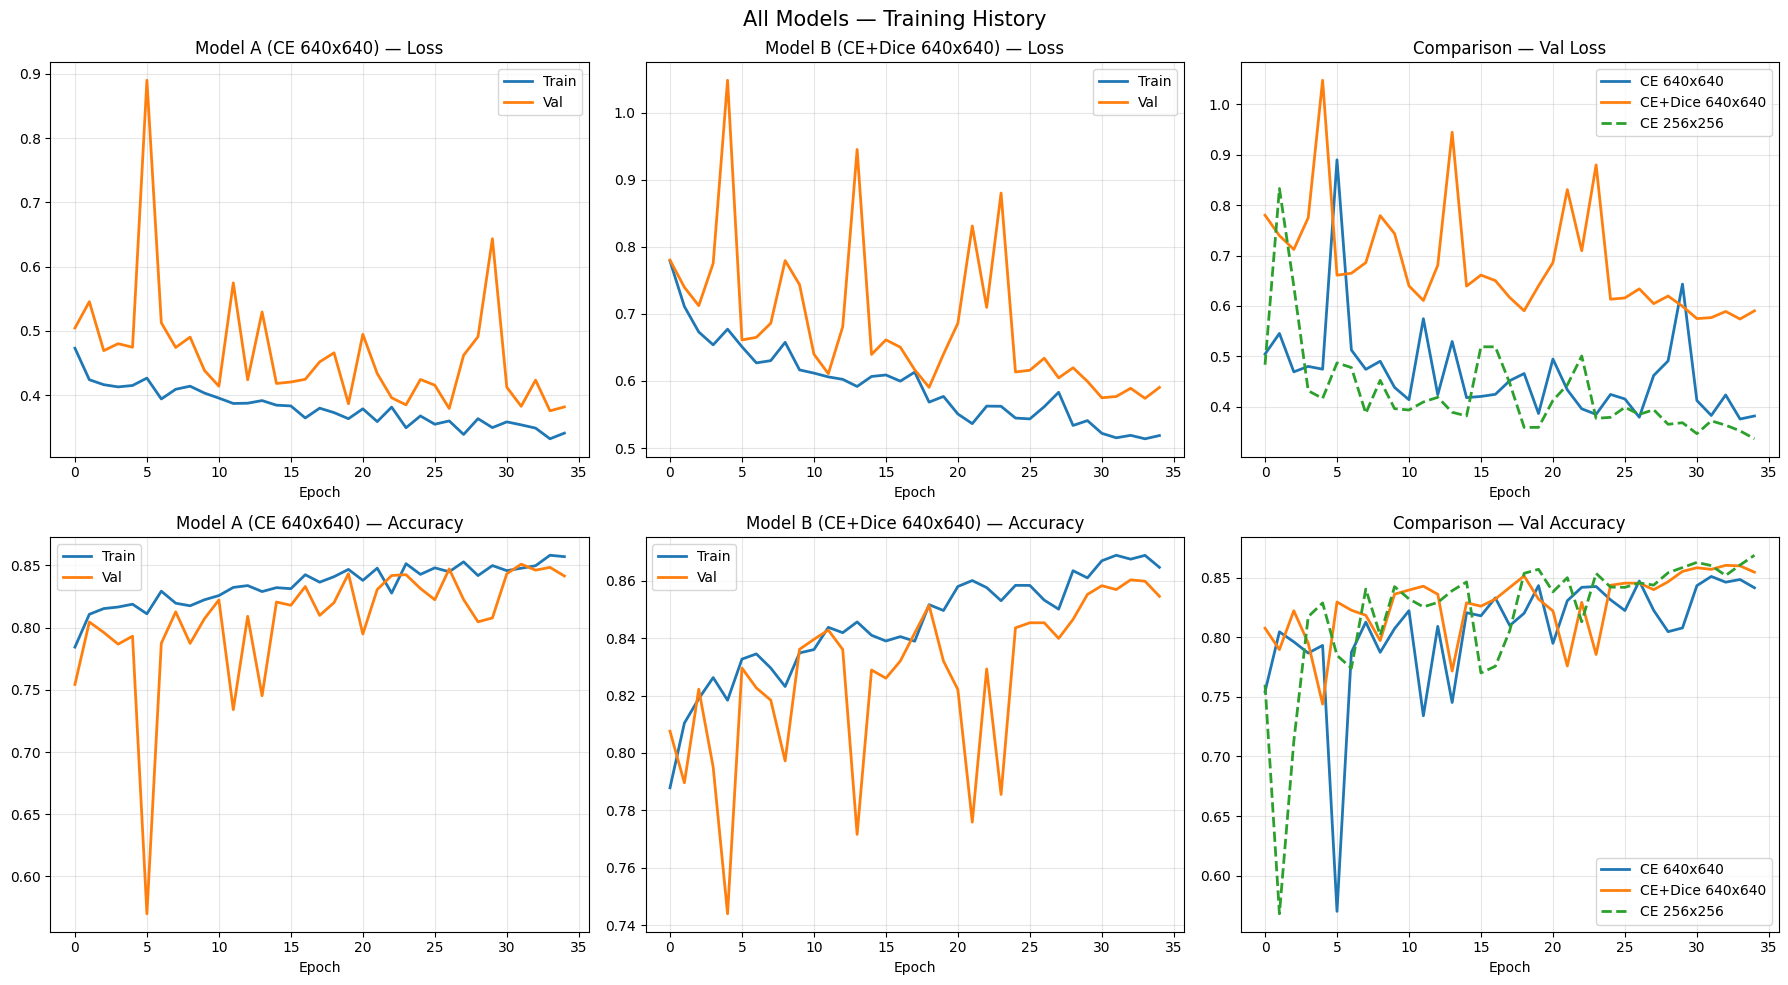


 FINAL EPOCH SUMMARY
Metric                        CE 640   Dice 640     CE 256
-------------------------------------------------------
Final Val Loss                0.3816     0.5904     0.3363
Final Val Acc                 0.8415     0.8546     0.8688


In [20]:
# ============================================================
# Plot all training curves
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

configs = [
    (ce_history,       'Model A (CE 640x640)'),
    (dice_history,     'Model B (CE+Dice 640x640)'),
    (low_res_history,  'Model C (CE 256x256)'),
]

# Individual loss plots
for ax, (hist, title) in zip(axes[0, :2], configs[:2]):
    ax.plot(hist['train_loss'], label='Train', linewidth=2)
    ax.plot(hist['val_loss'],   label='Val',   linewidth=2)
    ax.set_title(f'{title} — Loss'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

# Comparison val loss
axes[0, 2].plot(ce_history['val_loss'],      label='CE 640x640',      linewidth=2)
axes[0, 2].plot(dice_history['val_loss'],    label='CE+Dice 640x640', linewidth=2)
axes[0, 2].plot(low_res_history['val_loss'], label='CE 256x256',      linewidth=2, linestyle='--')
axes[0, 2].set_title('Comparison — Val Loss'); axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

# Individual accuracy plots
for ax, (hist, title) in zip(axes[1, :2], configs[:2]):
    ax.plot(hist['train_acc'], label='Train', linewidth=2)
    ax.plot(hist['val_acc'],   label='Val',   linewidth=2)
    ax.set_title(f'{title} — Accuracy'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

# Comparison val accuracy
axes[1, 2].plot(ce_history['val_acc'],      label='CE 640x640',      linewidth=2)
axes[1, 2].plot(dice_history['val_acc'],    label='CE+Dice 640x640', linewidth=2)
axes[1, 2].plot(low_res_history['val_acc'], label='CE 256x256',      linewidth=2, linestyle='--')
axes[1, 2].set_title('Comparison — Val Accuracy'); axes[1, 2].set_xlabel('Epoch')
axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('All Models — Training History', fontsize=15)
plt.tight_layout(); plt.show()

print(f"\n{'='*60}")
print(f" FINAL EPOCH SUMMARY")
print(f"{'='*60}")
print(f"{'Metric':<25} {'CE 640':>10} {'Dice 640':>10} {'CE 256':>10}")
print(f"{'-'*55}")
for key, label in [('val_loss', 'Final Val Loss'), ('val_acc', 'Final Val Acc')]:
    print(f"{label:<25} {ce_history[key][-1]:>10.4f} "
          f"{dice_history[key][-1]:>10.4f} {low_res_history[key][-1]:>10.4f}")

## 14. Evaluation Metrics

In [21]:
# ============================================================
# IoU and Dice per class
# ============================================================
def compute_iou_per_class(y_true, y_pred, num_classes=NUM_CLASSES):
    ious = []
    for c in range(num_classes):
        tp = ((y_pred == c) & (y_true == c)).sum()
        fp = ((y_pred == c) & (y_true != c)).sum()
        fn = ((y_pred != c) & (y_true == c)).sum()
        union = tp + fp + fn
        ious.append(float('nan') if union == 0 else tp / union)
    return ious

def compute_dice_per_class(y_true, y_pred, num_classes=NUM_CLASSES):
    dices = []
    for c in range(num_classes):
        tp    = ((y_pred == c) & (y_true == c)).sum()
        fp    = ((y_pred == c) & (y_true != c)).sum()
        fn    = ((y_pred != c) & (y_true == c)).sum()
        total = 2 * tp + fp + fn
        dices.append(float('nan') if total == 0 else (2 * tp) / total)
    return dices


@torch.no_grad()
def evaluate_model(model, loader, model_name):
    model.eval()
    all_ious, all_dices = [], []
    for images, masks in loader:
        images = images.to(DEVICE)
        logits = model(images)
        preds  = logits.argmax(dim=1).cpu().numpy()
        masks  = masks.numpy()
        for i in range(preds.shape[0]):
            all_ious.append(compute_iou_per_class(masks[i],  preds[i]))
            all_dices.append(compute_dice_per_class(masks[i], preds[i]))

    all_ious   = np.array(all_ious,  dtype=float)
    all_dices  = np.array(all_dices, dtype=float)
    mean_ious  = np.nanmean(all_ious,  axis=0)
    mean_dices = np.nanmean(all_dices, axis=0)
    miou  = np.nanmean(mean_ious)
    mdice = np.nanmean(mean_dices)

    print(f"\n{'='*55}\n {model_name.upper()}\n{'='*55}")
    print(f"{'Class':<15} {'IoU':>10} {'Dice':>10}")
    print('-' * 38)
    for i, name in enumerate(CLASS_NAMES):
        print(f"{name:<15} {mean_ious[i]:>10.4f} {mean_dices[i]:>10.4f}")
    print('-' * 38)
    print(f"{'mIoU':<15} {miou:>10.4f} {mdice:>10.4f}")
    return all_ious, all_dices, mean_ious, mean_dices, miou, mdice


print("Evaluating on TEST SET...")
ce_all_ious,   ce_all_dices,   ce_mean_ious,   ce_mean_dices,   ce_miou,   ce_mdice   = evaluate_model(full_unet_ce,   test_loader,     'CE Loss 640x640')
dice_all_ious, dice_all_dices, dice_mean_ious, dice_mean_dices, dice_miou, dice_mdice = evaluate_model(full_unet_dice, test_loader,     'CE+Dice Loss 640x640')
lr_all_ious,   lr_all_dices,   lr_mean_ious,   lr_mean_dices,   lr_miou,   lr_mdice   = evaluate_model(unet_low_res,   test_loader_low, 'CE Loss 256x256')

Evaluating on TEST SET...

 CE LOSS 640X640
Class                  IoU       Dice
--------------------------------------
Background          0.7977     0.8821
Flood               0.6967     0.8023
--------------------------------------
mIoU                0.7472     0.8422

 CE+DICE LOSS 640X640
Class                  IoU       Dice
--------------------------------------
Background          0.8219     0.8990
Flood               0.7500     0.8425
--------------------------------------
mIoU                0.7860     0.8708

 CE LOSS 256X256
Class                  IoU       Dice
--------------------------------------
Background          0.8135     0.8931
Flood               0.7396     0.8351
--------------------------------------
mIoU                0.7765     0.8641


In [22]:
# ============================================================
# Complete comparison table
# ============================================================
print(f"\n{'='*70}")
print(f"  COMPLETE MODEL COMPARISON")
print(f"{'='*70}")
print(f"{'Model':<35} {'Resolution':>10} {'mIoU':>8} {'Mean Dice':>10}")
print(f"{'-'*65}")
print(f"{'Full U-Net (CE)':<35} {'640x640':>10} {ce_miou:>8.4f} {ce_mdice:>10.4f}")
print(f"{'Full U-Net (CE+Dice)':<35} {'640x640':>10} {dice_miou:>8.4f} {dice_mdice:>10.4f}")
print(f"{'Full U-Net (CE, low-res)':<35} {'256x256':>10} {lr_miou:>8.4f} {lr_mdice:>10.4f}")
print(f"\nResolution impact: {((ce_miou - lr_miou)/lr_miou*100):+.1f}% mIoU from 256->640")
print(f"Best loss function: {'CE+Dice' if dice_miou > ce_miou else 'CE only'}")

print(f"\n{'='*65}")
print(f"  PER-CLASS IoU")
print(f"{'='*65}")
print(f"{'Class':<15} {'CE 640x640':>12} {'CE+Dice 640x640':>16} {'CE 256x256':>12}")
print('-'*58)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {ce_mean_ious[i]:>12.4f} {dice_mean_ious[i]:>16.4f} {lr_mean_ious[i]:>12.4f}")
print('-'*58)
print(f"{'mIoU':<15} {ce_miou:>12.4f} {dice_miou:>16.4f} {lr_miou:>12.4f}")


  COMPLETE MODEL COMPARISON
Model                               Resolution     mIoU  Mean Dice
-----------------------------------------------------------------
Full U-Net (CE)                        640x640   0.7472     0.8422
Full U-Net (CE+Dice)                   640x640   0.7860     0.8708
Full U-Net (CE, low-res)               256x256   0.7765     0.8641

Resolution impact: -3.8% mIoU from 256->640
Best loss function: CE+Dice

  PER-CLASS IoU
Class             CE 640x640  CE+Dice 640x640   CE 256x256
----------------------------------------------------------
Background            0.7977           0.8219       0.8135
Flood                 0.6967           0.7500       0.7396
----------------------------------------------------------
mIoU                  0.7472           0.7860       0.7765


## 15. Visualizations

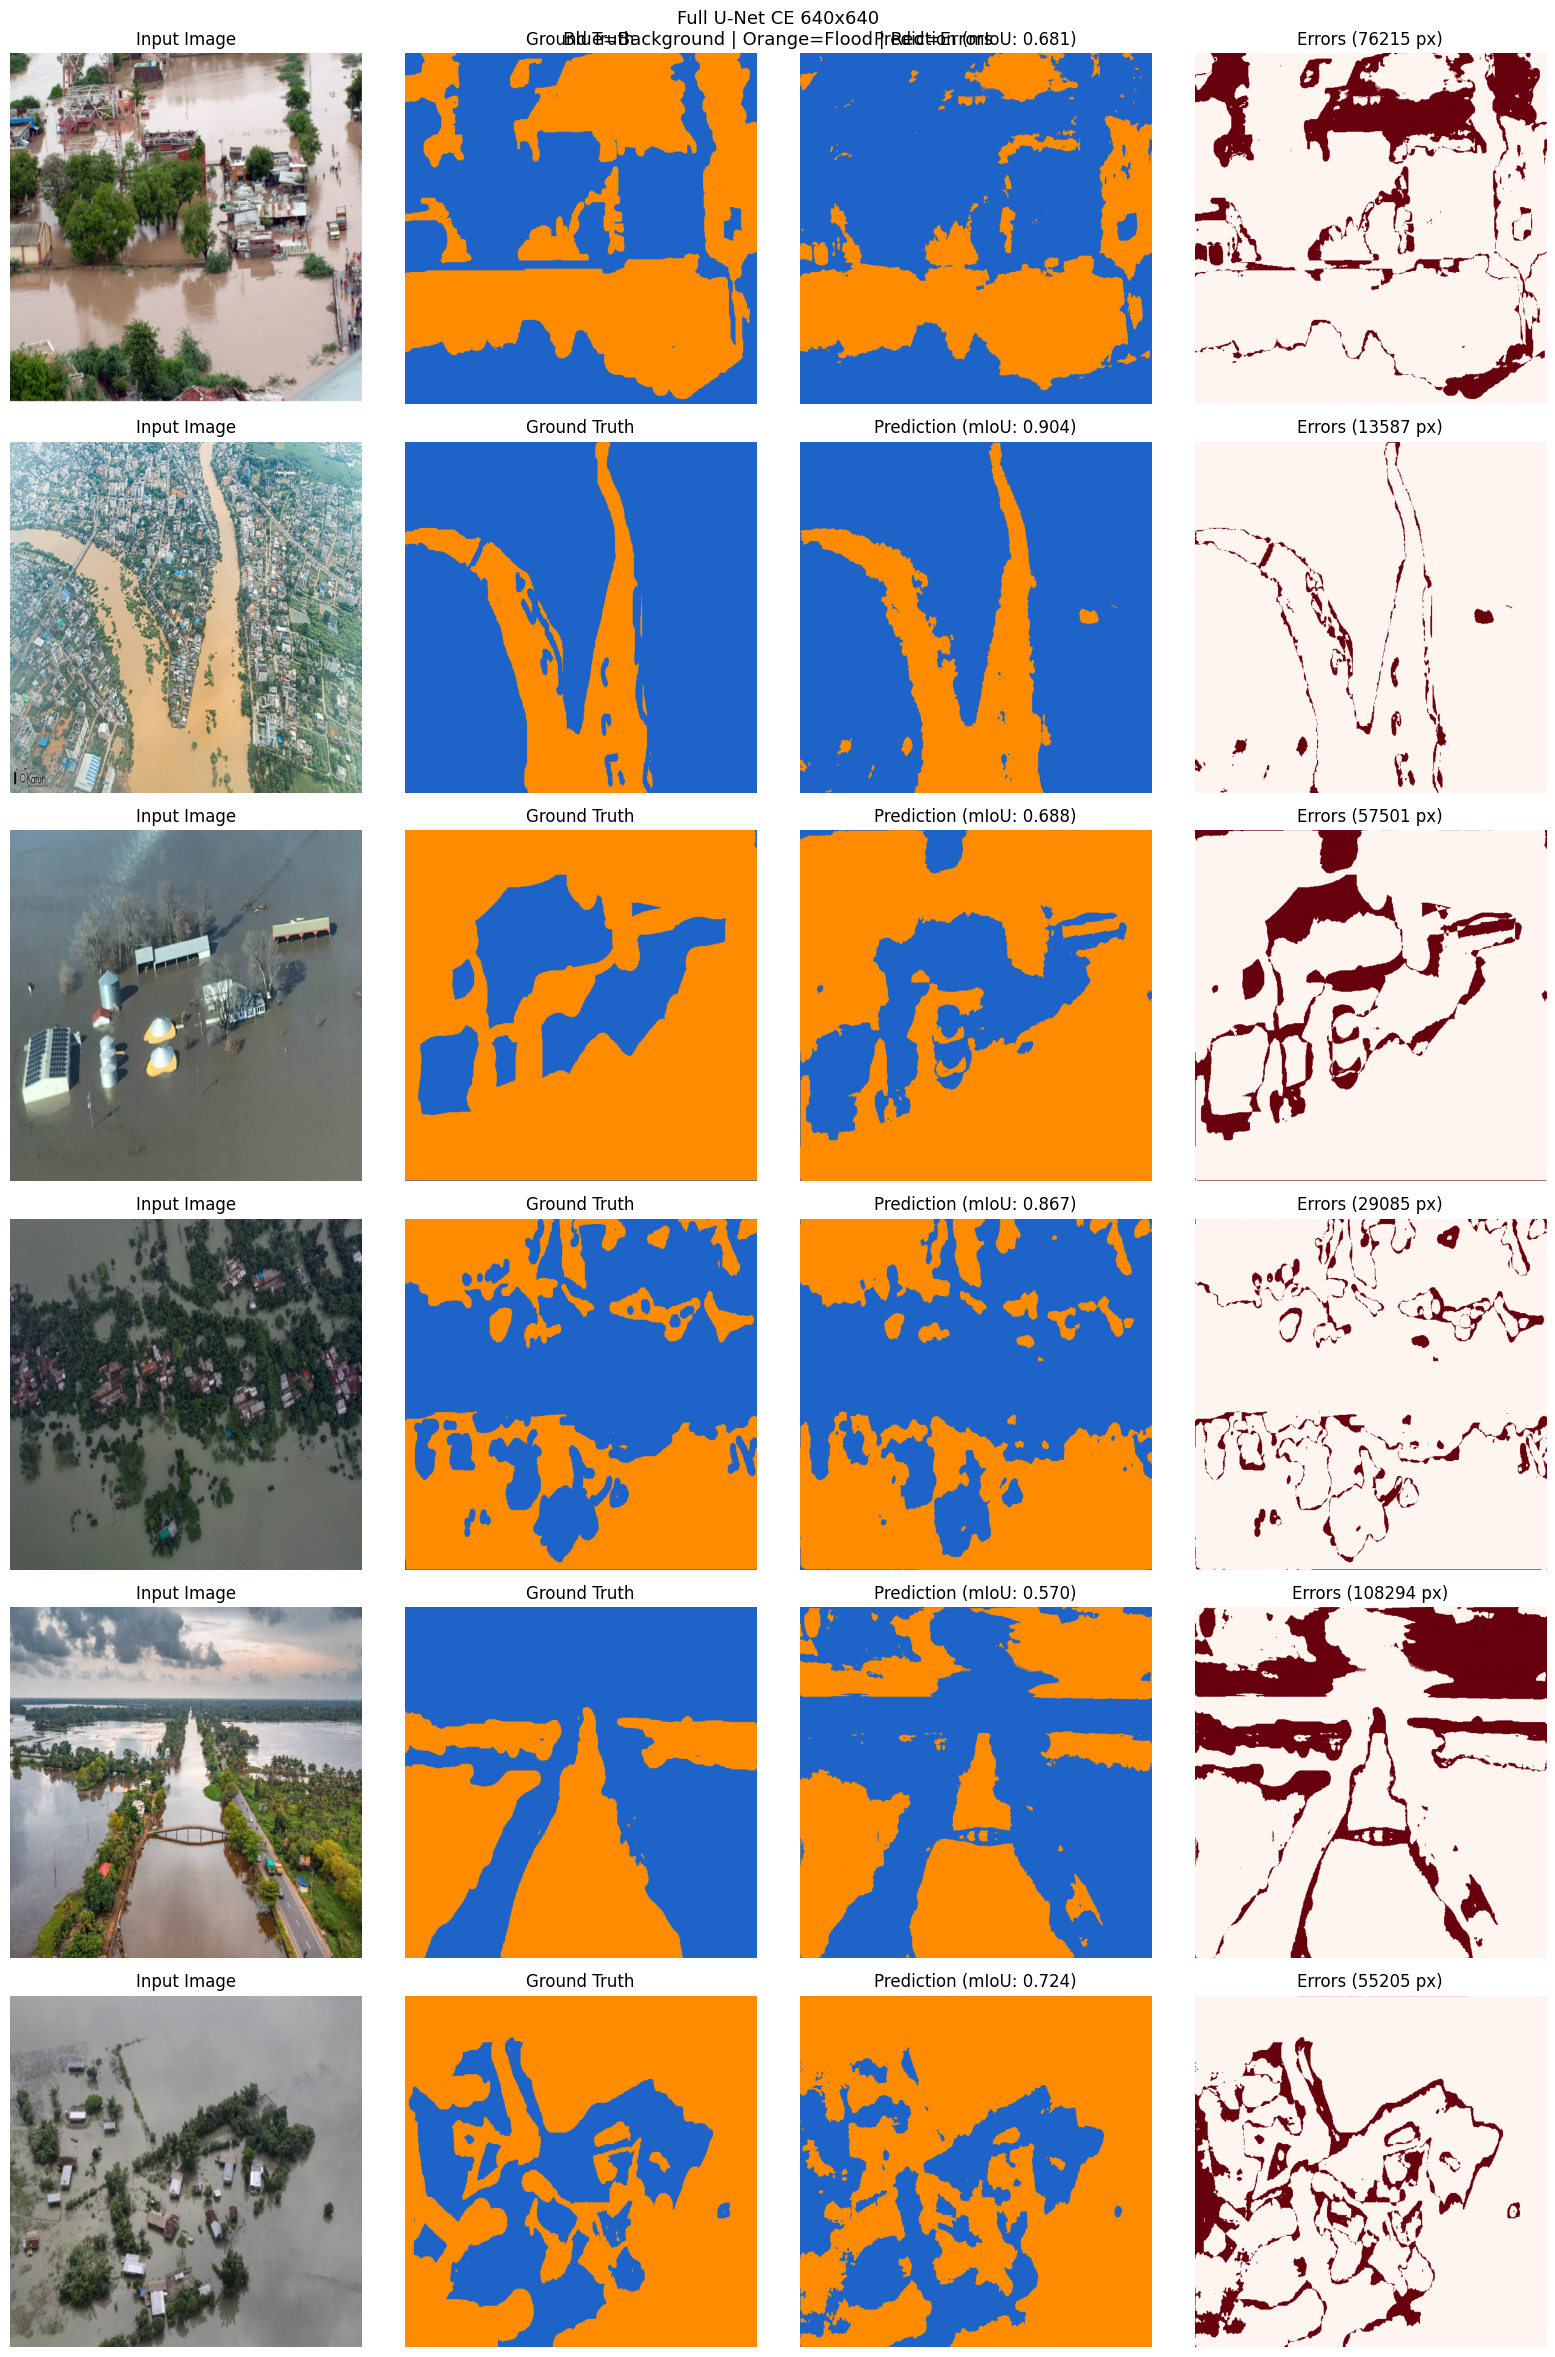

In [23]:
# ============================================================
# 6 prediction examples with error maps
# ============================================================
@torch.no_grad()
def show_detailed_predictions(model, loader, num_samples=6, title='Full U-Net'):
    model.eval()
    collected_imgs, collected_masks, collected_preds = [], [], []
    for images, masks in loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        collected_imgs.extend(images.cpu().permute(0,2,3,1).numpy())
        collected_masks.extend(masks.numpy())
        collected_preds.extend(preds)
        if len(collected_imgs) >= num_samples:
            break

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    for i in range(num_samples):
        img, true_mask, pred_mask = collected_imgs[i], collected_masks[i], collected_preds[i]
        error_map = (pred_mask != true_mask).astype(float)
        miou_img  = np.nanmean(compute_iou_per_class(true_mask, pred_mask))
        axes[i,0].imshow(img);                   axes[i,0].set_title('Input Image');                        axes[i,0].axis('off')
        axes[i,1].imshow(COLORMAP[true_mask]);   axes[i,1].set_title('Ground Truth');                       axes[i,1].axis('off')
        axes[i,2].imshow(COLORMAP[pred_mask]);   axes[i,2].set_title(f'Prediction (mIoU: {miou_img:.3f})'); axes[i,2].axis('off')
        axes[i,3].imshow(error_map, cmap='Reds');axes[i,3].set_title(f'Errors ({error_map.sum():.0f} px)'); axes[i,3].axis('off')
    plt.suptitle(f'{title}\nBlue=Background | Orange=Flood | Red=Errors', fontsize=13)
    plt.tight_layout(); plt.show()

show_detailed_predictions(full_unet_ce, test_loader, title='Full U-Net CE 640x640')

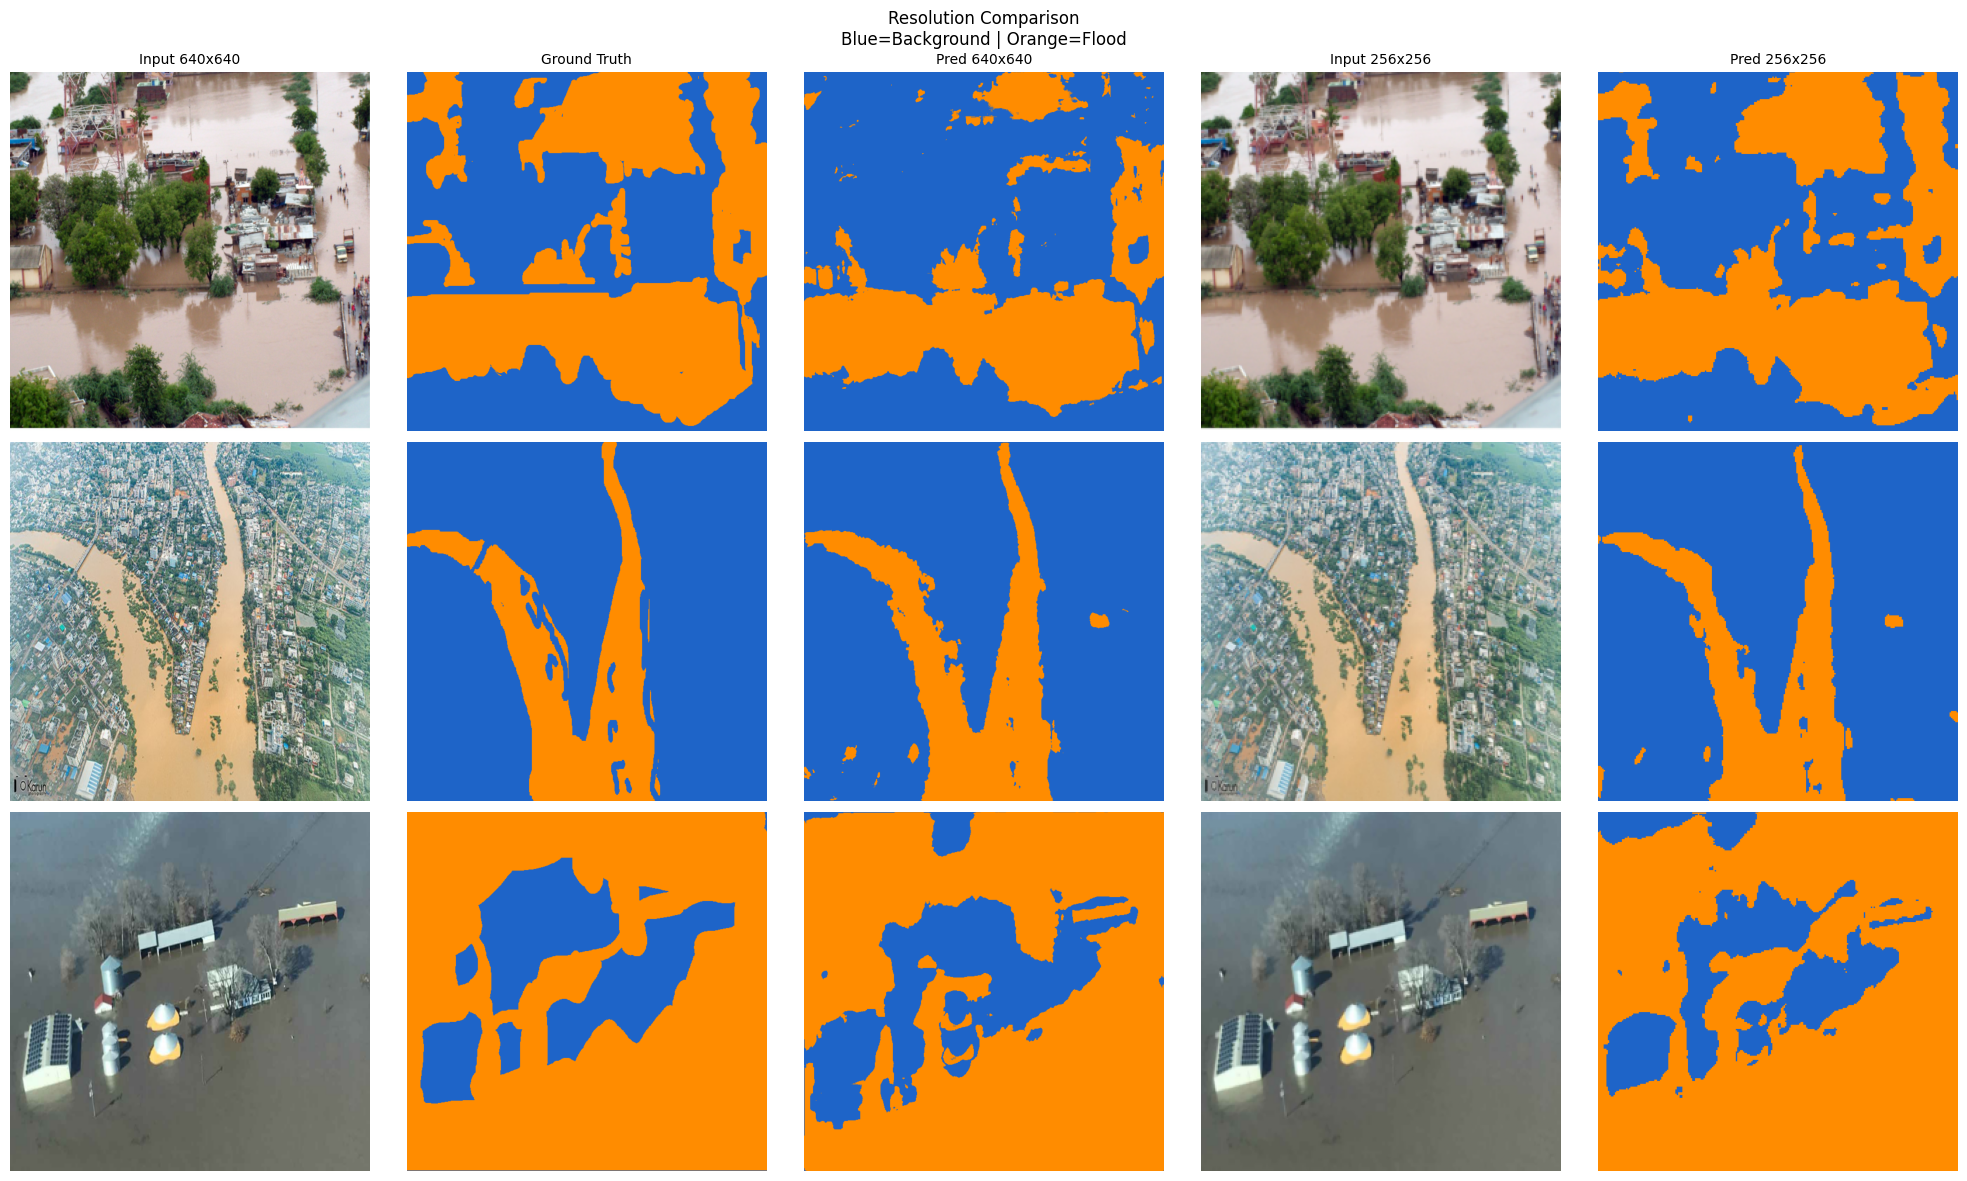

In [24]:
# ============================================================
# Resolution comparison — side by side
# ============================================================
@torch.no_grad()
def show_resolution_comparison(model_hi, model_lo, loader_hi, loader_lo, num_samples=3):
    model_hi.eval(); model_lo.eval()
    hi_iter = iter(loader_hi)
    lo_iter = iter(loader_lo)

    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4 * num_samples))
    for ax, t in zip(axes[0], ['Input 640x640','Ground Truth','Pred 640x640','Input 256x256','Pred 256x256']):
        ax.set_title(t, fontsize=10)

    imgs_hi, msks_hi = next(hi_iter)
    imgs_lo, _       = next(lo_iter)
    preds_hi = model_hi(imgs_hi.to(DEVICE)).argmax(1).cpu().numpy()
    preds_lo = model_lo(imgs_lo.to(DEVICE)).argmax(1).cpu().numpy()

    for i in range(num_samples):
        axes[i,0].imshow(imgs_hi[i].permute(1,2,0).numpy());  axes[i,0].axis('off')
        axes[i,1].imshow(COLORMAP[msks_hi[i].numpy()]);       axes[i,1].axis('off')
        axes[i,2].imshow(COLORMAP[preds_hi[i]]);              axes[i,2].axis('off')
        axes[i,3].imshow(imgs_lo[i].permute(1,2,0).numpy());  axes[i,3].axis('off')
        axes[i,4].imshow(COLORMAP[preds_lo[i]]);              axes[i,4].axis('off')

    plt.suptitle('Resolution Comparison\nBlue=Background | Orange=Flood', fontsize=12)
    plt.tight_layout(); plt.show()

show_resolution_comparison(full_unet_ce, unet_low_res, test_loader, test_loader_low)

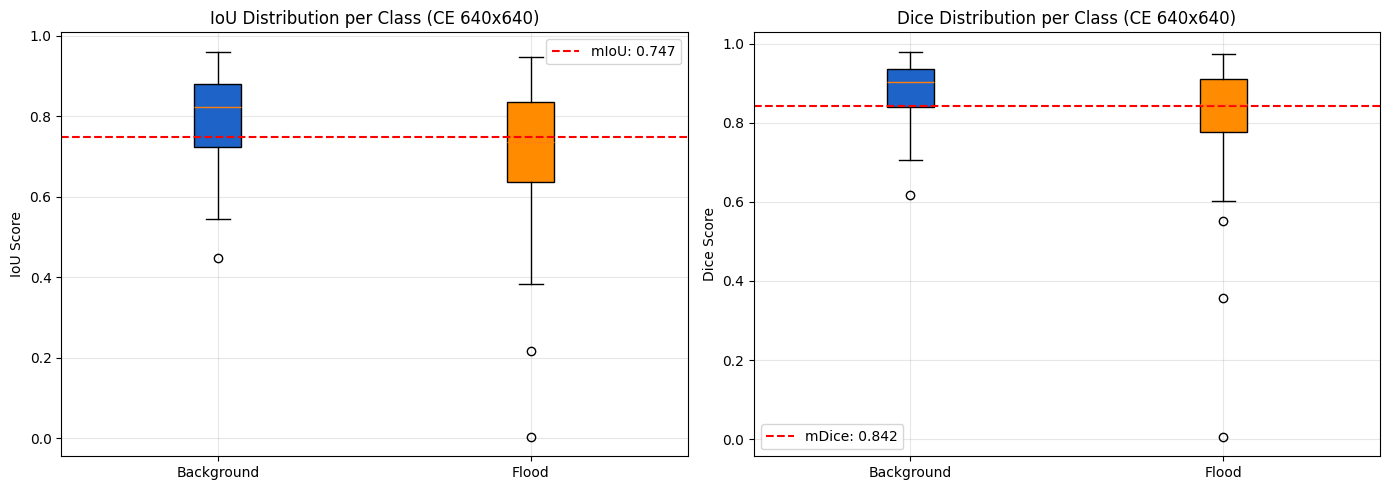

In [25]:
# ============================================================
# Box plots — per-class score distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1e64c8', '#ff8c00']

iou_data  = [ce_all_ious[:, c][~np.isnan(ce_all_ious[:, c])]   for c in range(NUM_CLASSES)]
dice_data = [ce_all_dices[:, c][~np.isnan(ce_all_dices[:, c])] for c in range(NUM_CLASSES)]

for ax, data, ylabel, title in zip(
    axes, [iou_data, dice_data],
    ['IoU Score', 'Dice Score'],
    ['IoU Distribution per Class (CE 640x640)', 'Dice Distribution per Class (CE 640x640)']
):
    bp = ax.boxplot(data, tick_labels=CLASS_NAMES, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(True, alpha=0.3)

axes[0].axhline(ce_miou,  color='red', linestyle='--', label=f'mIoU: {ce_miou:.3f}');  axes[0].legend()
axes[1].axhline(ce_mdice, color='red', linestyle='--', label=f'mDice: {ce_mdice:.3f}'); axes[1].legend()
plt.tight_layout(); plt.show()

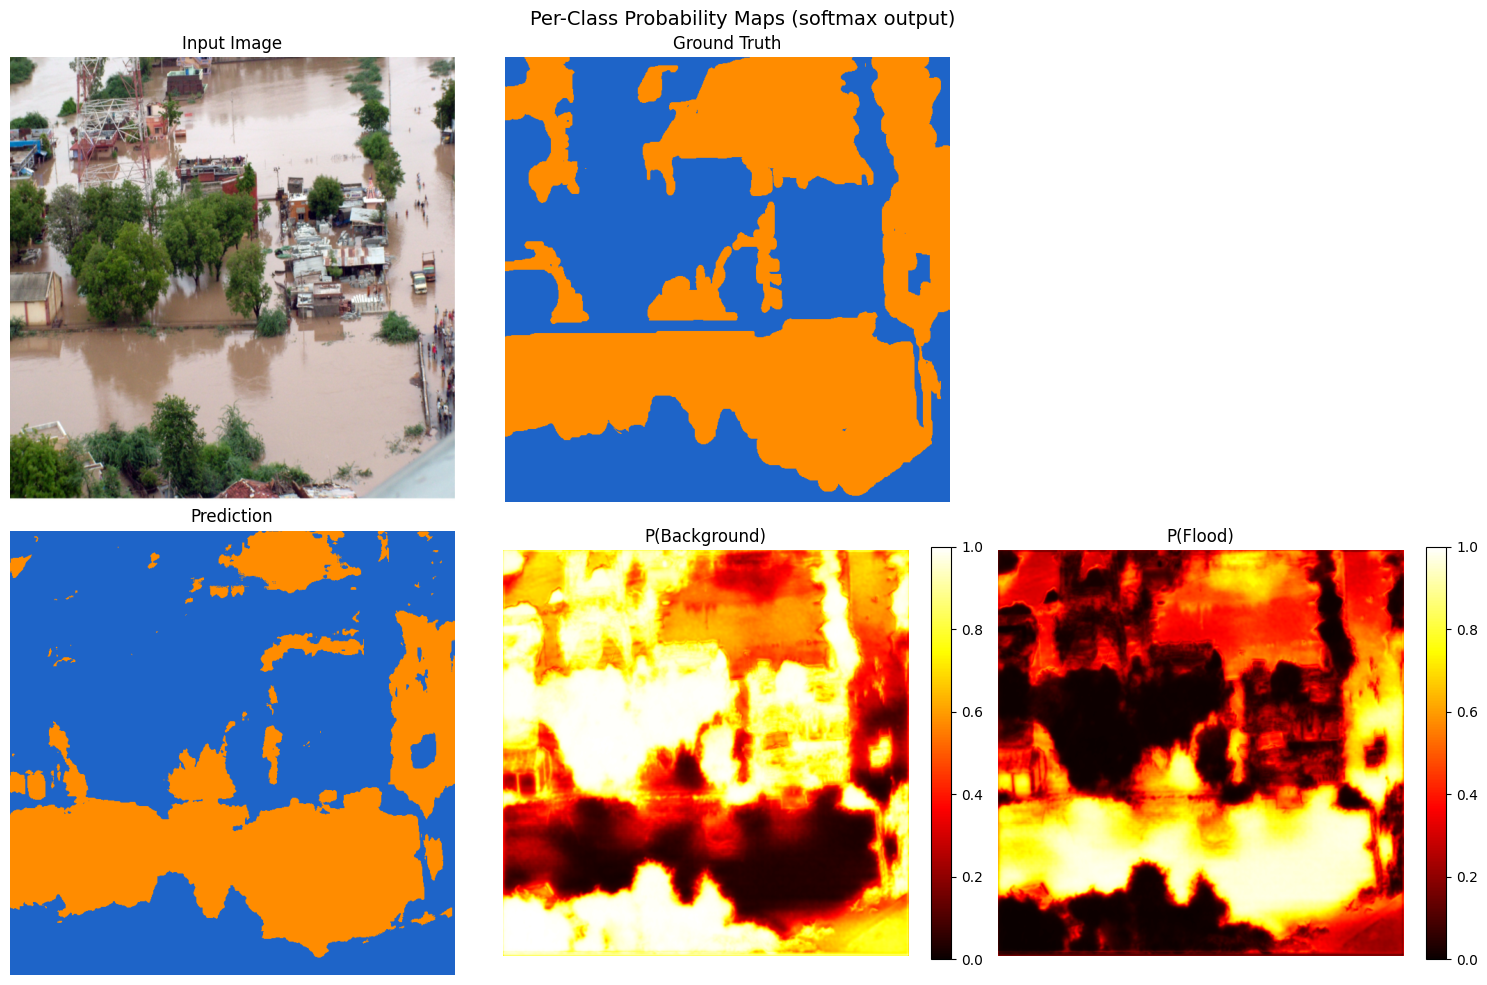

In [26]:
# ============================================================
# Probability maps
# ============================================================
@torch.no_grad()
def show_probability_maps(model, loader):
    model.eval()
    images, masks = next(iter(loader))
    image = images[0:1].to(DEVICE)
    logits = model(image)
    probs  = F.softmax(logits, dim=1)[0].cpu().numpy()  # (C, H, W)
    pred_mask = logits.argmax(1)[0].cpu().numpy()
    true_mask = masks[0].numpy()

    fig, axes = plt.subplots(2, NUM_CLASSES + 1, figsize=(5 * (NUM_CLASSES + 1), 10))
    axes[0, 0].imshow(images[0].permute(1,2,0).numpy()); axes[0, 0].set_title('Input Image');  axes[0, 0].axis('off')
    axes[0, 1].imshow(COLORMAP[true_mask]);               axes[0, 1].set_title('Ground Truth'); axes[0, 1].axis('off')
    axes[1, 0].imshow(COLORMAP[pred_mask]);               axes[1, 0].set_title('Prediction');   axes[1, 0].axis('off')
    for c in range(NUM_CLASSES):
        im = axes[1, c + 1].imshow(probs[c], cmap='hot', vmin=0, vmax=1)
        axes[1, c + 1].set_title(f'P({CLASS_NAMES[c]})'); axes[1, c + 1].axis('off')
        plt.colorbar(im, ax=axes[1, c + 1], fraction=0.046)
    # hide unused top-right
    for c in range(2, NUM_CLASSES + 1):
        axes[0, c].axis('off')
    plt.suptitle('Per-Class Probability Maps (softmax output)', fontsize=14)
    plt.tight_layout(); plt.show()

show_probability_maps(full_unet_ce, test_loader)

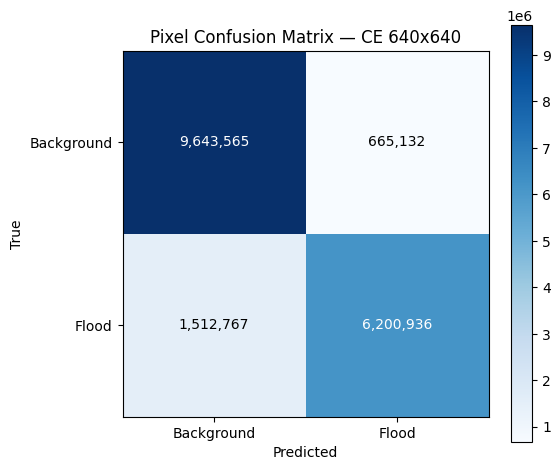

In [27]:
# ============================================================
# Pixel-level confusion matrix
# ============================================================
@torch.no_grad()
def plot_confusion_matrix(model, loader, title='Confusion Matrix'):
    model.eval()
    all_true, all_pred = [], []
    for images, masks in loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu().numpy().flatten()
        all_true.append(masks.numpy().flatten())
        all_pred.append(preds)
    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)
    cm = confusion_matrix(all_true, all_pred, labels=list(range(NUM_CLASSES)))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES),
           xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
           xlabel='Predicted', ylabel='True', title=title)
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j] > thresh else 'black', fontsize=10)
    plt.tight_layout(); plt.show()

plot_confusion_matrix(full_unet_ce, test_loader, title='Pixel Confusion Matrix — CE 640x640')